# Pitch Tracking

This notebook estimates fundamental frequency with YIN and compares it with dominant FFT-bin frequency.


> Run these notebooks from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math

import matplotlib.pyplot as plt
import spafe

In [2]:
fs = 16_000
seconds = 1.0
base = 220.0
# A simple two-tone signal makes the dominant-bin estimate visibly different from YIN.
signal = [
    0.8 * math.sin(2.0 * math.pi * base * n / fs)
    + 0.25 * math.sin(2.0 * math.pi * 2.0 * base * n / fs)
    for n in range(int(fs * seconds))
]
print(f"samples={len(signal)}")

samples=16000


In [3]:
pitches, harmonic_rates, argmins, times = spafe.compute_yin(
    signal,
    fs=fs,
    win_len=0.03,
    win_hop=0.015,
    low_freq=50.0,
    high_freq=1_000.0,
    harmonic_threshold=0.1,
)

dominant = spafe.get_dominant_frequencies(
    signal,
    fs=fs,
    nfft=512,
    win_len=0.025,
    win_hop=0.010,
)
dominant_times = [idx * 0.010 for idx in range(len(dominant))]
print(f"YIN frames={len(pitches)}, dominant frames={len(dominant)}")

YIN frames=65, dominant frames=98


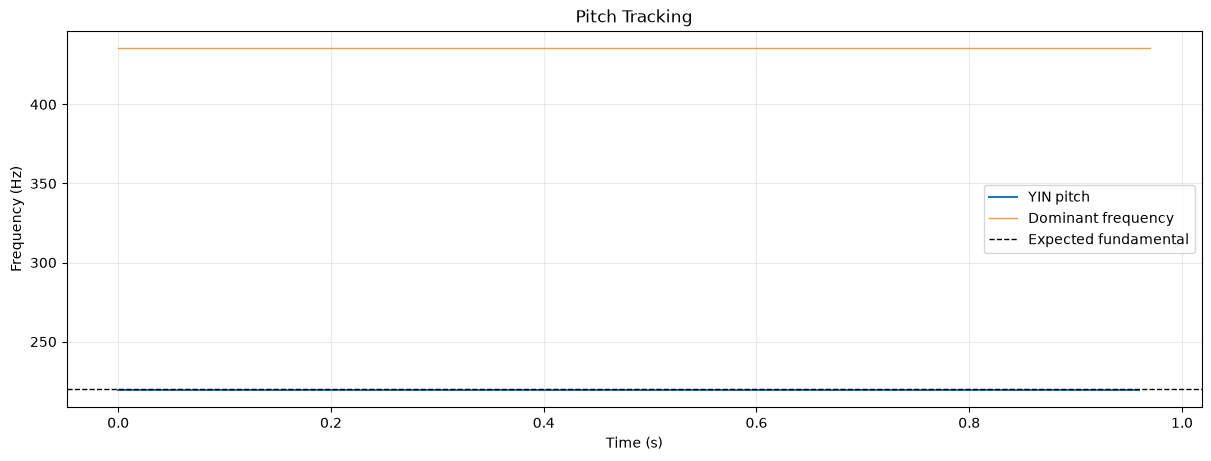

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.plot(times, pitches, label="YIN pitch", linewidth=1.5)
ax.plot(dominant_times, dominant, label="Dominant frequency", linewidth=1.0, alpha=0.8)
ax.axhline(
    base, color="black", linestyle="--", linewidth=1.0, label="Expected fundamental"
)
ax.set_title("Pitch Tracking")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

In [5]:
voiced = [pitch for pitch in pitches if pitch > 0.0]
print(f"average voiced pitch: {sum(voiced) / len(voiced):.3f} Hz")
print(f"average harmonic rate: {sum(harmonic_rates) / len(harmonic_rates):.6f}")

average voiced pitch: 219.178 Hz
average harmonic rate: 0.000324
